# 📊 Notebook 01 — Data Engineering
**Project:** Volatility-Regime-Conditioned DDPM for NIFTY50 Synthetic Returns  
**IIT Mandi Internship · Quant × GenAI**

---
## What this notebook does
1. Downloads NIFTY50 and India VIX data from Yahoo Finance  
2. Computes log returns  
3. Performs a strict chronological train/test split  
4. Z-score normalises returns (train stats only — no leakage)  
5. Assigns binary volatility regime labels (Low/High via median VIX)  
6. Creates overlapping sliding windows → PyTorch tensors  
7. Runs sanity checks  

**Output:** `data/windows/train_windows.pt` and `data/windows/test_windows.pt`  
**Each sample:** `(returns [64], avg_vix [1], regime_label [1])`

---
> ⚠️ **Run all cells top to bottom. Do not skip cells.**

## Cell 1 — Install & Import Dependencies

In [1]:
# Install missing packages (safe to re-run)
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

install('yfinance')
install('pyyaml')

print('✅ Dependencies ready')

✅ Dependencies ready


In [2]:
import os
import yaml
import numpy as np
import pandas as pd
import torch
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'PyTorch version : {torch.__version__}')
print(f'NumPy   version : {np.__version__}')
print(f'Pandas  version : {pd.__version__}')
print('✅ All imports successful')

PyTorch version : 2.13.0+cpu
NumPy   version : 2.4.6
Pandas  version : 3.0.3
✅ All imports successful


## Cell 2 — Load Configuration

In [3]:
# ── Load config.yaml ──────────────────────────────────────────
CONFIG_PATH = os.path.join('..', 'configs', 'config.yaml')

with open(CONFIG_PATH, 'r') as f:
    cfg = yaml.safe_load(f)

# ── Resolve paths relative to this notebook ──────────────────
BASE_DIR    = os.path.abspath(os.path.join(os.getcwd(), '..'))
RAW_DIR     = os.path.join(BASE_DIR, 'data', 'raw')
PROC_DIR    = os.path.join(BASE_DIR, 'data', 'processed')
WIN_DIR     = os.path.join(BASE_DIR, 'data', 'windows')
FIG_DIR     = os.path.join(BASE_DIR, 'outputs', 'figures')

for d in [RAW_DIR, PROC_DIR, WIN_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Convenience aliases ───────────────────────────────────────
NIFTY_TICKER  = cfg['data']['nifty_ticker']
VIX_TICKER    = cfg['data']['vix_ticker']
START_DATE    = cfg['data']['start_date']
END_DATE      = cfg['data']['end_date']
TRAIN_END     = cfg['data']['train_end_date']
WINDOW_SIZE   = cfg['data']['window_size']
STRIDE        = cfg['data']['stride']

print('Config loaded ✅')
print(f'  Tickers    : {NIFTY_TICKER}, {VIX_TICKER}')
print(f'  Date range : {START_DATE}  →  {END_DATE}')
print(f'  Train end  : {TRAIN_END}')
print(f'  Window     : {WINDOW_SIZE} days, stride={STRIDE}')

Config loaded ✅
  Tickers    : ^NSEI, ^INDIAVIX
  Date range : 2008-01-01  →  2026-07-01
  Train end  : 2022-12-31
  Window     : 64 days, stride=1


## Cell 3 — Download Raw Data from Yahoo Finance

> **Edge case handled:** India VIX data starts around March 2009 — we take the **intersection** of available dates automatically.

In [4]:
print('Downloading NIFTY50...')
nifty_raw = yf.download(NIFTY_TICKER, start=START_DATE, end=END_DATE,
                         progress=False, auto_adjust=True)
nifty_close = nifty_raw[['Close']].rename(columns={'Close': 'NIFTY'})

print('Downloading India VIX...')
vix_raw = yf.download(VIX_TICKER, start=START_DATE, end=END_DATE,
                       progress=False, auto_adjust=True)
vix_close = vix_raw[['Close']].rename(columns={'Close': 'VIX'})

# Flatten MultiIndex columns if yfinance returns them
if isinstance(nifty_close.columns, pd.MultiIndex):
    nifty_close.columns = ['NIFTY']
if isinstance(vix_close.columns, pd.MultiIndex):
    vix_close.columns = ['VIX']

# ── Inner join — takes date intersection automatically ────────
raw_df = nifty_close.join(vix_close, how='inner')
raw_df.index = pd.to_datetime(raw_df.index)
raw_df.sort_index(inplace=True)

# Save raw
raw_df.to_csv(os.path.join(RAW_DIR, 'nifty_vix_raw.csv'))

print(f'\nRaw data shape : {raw_df.shape}')
print(f'Date range     : {raw_df.index[0].date()}  →  {raw_df.index[-1].date()}')
print(f'NaN count      : NIFTY={raw_df["NIFTY"].isna().sum()}, VIX={raw_df["VIX"].isna().sum()}')
print('✅ Raw data downloaded and saved')
raw_df.head()


Raw data shape : (4471, 2)
Date range     : 2008-03-03  →  2026-06-30
NaN count      : NIFTY=0, VIX=0
✅ Raw data downloaded and saved


,NIFTY,VIX
Date,,
2008-03-03,4953.000000,35.759998
2008-03-04,4864.250000,38.080002
2008-03-05,4921.399902,35.509998
2008-03-07,4771.600098,35.200001
2008-03-10,4800.399902,32.580002


## Cell 4 — Compute Log Returns

We model **log returns**, not prices.  
`r_t = log(P_t) - log(P_{t-1})`  

- Prices are non-stationary → cannot model directly  
- Log returns are approximately stationary  
- First row will be NaN → drop it

In [5]:
# ── Log returns ───────────────────────────────────────────────
clean_df = raw_df.copy()

# Forward-fill any stray NaNs in NIFTY / VIX first (e.g. holidays)
clean_df['NIFTY'].ffill(inplace=True)
clean_df['VIX'].ffill(inplace=True)

clean_df['log_return'] = np.log(clean_df['NIFTY'] / clean_df['NIFTY'].shift(1))

# Drop the first row (NaN return) and any remaining NaNs
clean_df.dropna(inplace=True)

print(f'After log-return + dropna: {len(clean_df)} rows')
print(f'Date range : {clean_df.index[0].date()}  →  {clean_df.index[-1].date()}')
print(f'\nLog-return statistics:')
print(clean_df['log_return'].describe().to_string())

# Quick sanity: returns should be roughly centered at 0
assert abs(clean_df['log_return'].mean()) < 0.005, 'Mean return unexpectedly large — check data'
assert clean_df['log_return'].std() < 0.1,         'Std dev unusually large — check data'

print('\n✅ Log returns computed. Sanity checks passed.')

After log-return + dropna: 4470 rows
Date range : 2008-03-04  →  2026-06-30

Log-return statistics:
count    4470.000000
mean        0.000352
std         0.012613
min        -0.139038
25%        -0.005191
50%         0.000596
75%         0.006487
max         0.163343

✅ Log returns computed. Sanity checks passed.


## Cell 5 — Chronological Train / Test Split

> **Rule: Never shuffle a time series.**  
> Train: 2009 → 2022 | Test: 2023 → 2026  
> We compute ALL normalisation stats from train only, then apply to both.

In [6]:
train_mask = clean_df.index <= TRAIN_END
test_mask  = clean_df.index  > TRAIN_END

train_df = clean_df[train_mask].copy()
test_df  = clean_df[test_mask].copy()

# ── Hard guard: no leakage ────────────────────────────────────
assert train_df.index.max() < test_df.index.min(), \
    '❌ LEAKAGE DETECTED: train and test dates overlap!'

print(f'Train : {len(train_df):>5} rows  '
      f'[{train_df.index[0].date()} → {train_df.index[-1].date()}]')
print(f'Test  : {len(test_df):>5} rows  '
      f'[{test_df.index[0].date()} → {test_df.index[-1].date()}]')
print(f'Split : {100*len(train_df)/(len(train_df)+len(test_df)):.1f}% train / '
      f'{100*len(test_df)/(len(train_df)+len(test_df)):.1f}% test')
print('\n✅ Chronological split done. No leakage.')

Train :  3616 rows  [2008-03-04 → 2022-12-30]
Test  :   854 rows  [2023-01-02 → 2026-06-30]
Split : 80.9% train / 19.1% test

✅ Chronological split done. No leakage.


## Cell 6 — Z-Score Normalisation

> **Critical rule:** Compute μ and σ on the **train set only**.  
> Apply those same values to the test set.  
> Store μ and σ — you will need them to de-normalise generated samples.

We normalise both **returns** and **VIX** separately.

In [7]:
# ── Return normalisation (train stats only) ───────────────────
ret_mean = train_df['log_return'].mean()
ret_std  = train_df['log_return'].std()

# ── VIX normalisation (train stats only) ─────────────────────
vix_mean = train_df['VIX'].mean()
vix_std  = train_df['VIX'].std()

# Apply to both splits
for df in [train_df, test_df]:
    df['norm_return'] = (df['log_return'] - ret_mean) / ret_std
    df['norm_vix']    = (df['VIX']        - vix_mean) / vix_std

# ── Save normalisation params ────────────────────────────────
norm_params = {
    'ret_mean': float(ret_mean),
    'ret_std' : float(ret_std),
    'vix_mean': float(vix_mean),
    'vix_std' : float(vix_std),
}
import json
with open(os.path.join(PROC_DIR, 'norm_params.json'), 'w') as f:
    json.dump(norm_params, f, indent=2)

print('Normalisation parameters (computed from train only):')
print(f'  Return  : μ = {ret_mean:.6f},  σ = {ret_std:.6f}')
print(f'  VIX     : μ = {vix_mean:.4f},  σ = {vix_std:.4f}')
print(f'\nTrain norm_return stats:')
print(f'  mean={train_df["norm_return"].mean():.4f}, std={train_df["norm_return"].std():.4f}  (should be ≈0, ≈1)')
print(f'\nSaved to: {PROC_DIR}/norm_params.json')

# Sanity: train normalised return should be ~N(0,1)
assert abs(train_df['norm_return'].mean()) < 0.01, 'Normalised mean not near 0'
assert abs(train_df['norm_return'].std() - 1.0)  < 0.01, 'Normalised std not near 1'

print('\n✅ Normalisation complete. Params saved.')

Normalisation parameters (computed from train only):
  Return  : μ = 0.000358,  σ = 0.013461
  VIX     : μ = 21.1931,  σ = 9.4275

Train norm_return stats:
  mean=0.0000, std=1.0000  (should be ≈0, ≈1)

Saved to: c:\Users\mahes\Downloads\IIT Mandi\nifty-ddpm\data\processed/norm_params.json

✅ Normalisation complete. Params saved.


## Cell 7 — Binary Regime Labels

**Why median split?**  
- Guarantees exactly 50/50 class balance in the train set  
- Threshold computed from train VIX only (no leakage)  
- Labels are used **only for evaluation bucketing** — the model sees continuous VIX

In [8]:
# ── Median computed from train only ──────────────────────────
vix_median_train = train_df['VIX'].median()

# Apply same threshold to test (so regimes are comparable)
for df in [train_df, test_df]:
    df['regime'] = (df['VIX'] > vix_median_train).astype(int)  # 0=Low, 1=High

print(f'VIX median (train) : {vix_median_train:.2f}')
print(f'\nTrain regime distribution:')
vc = train_df['regime'].value_counts().sort_index()
for label, count in vc.items():
    name = 'Low Vol ' if label == 0 else 'High Vol'
    pct  = 100 * count / len(train_df)
    print(f'  {name} (label={label}): {count:4d} days  ({pct:.1f}%)')

print(f'\nTest regime distribution:')
vc_test = test_df['regime'].value_counts().sort_index()
for label, count in vc_test.items():
    name = 'Low Vol ' if label == 0 else 'High Vol'
    pct  = 100 * count / len(test_df)
    print(f'  {name} (label={label}): {count:4d} days  ({pct:.1f}%)')

# Sanity: train should be ~50/50
train_high_pct = train_df['regime'].mean()
assert 0.45 < train_high_pct < 0.55, f'Train regime split is not near 50/50: {train_high_pct:.2f}'

print('\n✅ Binary regime labels assigned.')

# Save processed dataframes
train_df.to_csv(os.path.join(PROC_DIR, 'train_processed.csv'))
test_df.to_csv(os.path.join(PROC_DIR, 'test_processed.csv'))
print('   Processed CSVs saved to data/processed/')

VIX median (train) : 18.35

Train regime distribution:
  Low Vol  (label=0): 1808 days  (50.0%)
  High Vol (label=1): 1808 days  (50.0%)

Test regime distribution:
  Low Vol  (label=0):  784 days  (91.8%)
  High Vol (label=1):   70 days  (8.2%)

✅ Binary regime labels assigned.
   Processed CSVs saved to data/processed/


## Cell 8 — Sliding Window Creation

The DDPM doesn't eat single returns — it eats **sequences**.  

- Window size: **64 days** (≈3 months of trading)  
- Stride: **1** (maximum overlap → maximum samples)  
- Window VIX = **average VIX over the 64-day window** (more stable than last-day)  
- Window label = majority class over the window (for evaluation only)  

Each training sample: `(normalised_returns [64], normalised_avg_vix [1], regime_label [1])`

In [9]:
def create_windows(df, window_size, stride):
    """
    Creates sliding windows of normalised returns.
    
    Returns
    -------
    returns_windows : np.ndarray  shape (N, window_size)
    vix_windows     : np.ndarray  shape (N,)   — avg norm_vix over window
    regime_windows  : np.ndarray  shape (N,)   — majority regime over window
    window_dates    : list of str — end-date of each window (for debugging)
    """
    returns_arr = df['norm_return'].values
    norm_vix_arr = df['norm_vix'].values
    regime_arr  = df['regime'].values
    dates       = df.index

    returns_windows = []
    vix_windows     = []
    regime_windows  = []
    window_dates    = []

    n = len(df)
    for start in range(0, n - window_size + 1, stride):
        end = start + window_size

        ret_window    = returns_arr[start:end]       # [window_size]
        vix_window    = norm_vix_arr[start:end]       # [window_size]
        regime_window = regime_arr[start:end]         # [window_size]

        avg_vix    = vix_window.mean()                # scalar — condition for model
        maj_regime = int(regime_window.mean() >= 0.5) # majority vote

        returns_windows.append(ret_window)
        vix_windows.append(avg_vix)
        regime_windows.append(maj_regime)
        window_dates.append(str(dates[end - 1].date()))

    return (
        np.array(returns_windows, dtype=np.float32),
        np.array(vix_windows,     dtype=np.float32),
        np.array(regime_windows,  dtype=np.int64),
        window_dates
    )


# ── Build windows ─────────────────────────────────────────────
print('Building train windows...')
train_ret, train_vix, train_reg, train_dates = create_windows(train_df, WINDOW_SIZE, STRIDE)

print('Building test windows...')
test_ret, test_vix, test_reg, test_dates = create_windows(test_df, WINDOW_SIZE, STRIDE)

print(f'\nTrain windows : {len(train_ret):,}   shape={train_ret.shape}')
print(f'Test  windows : {len(test_ret):,}   shape={test_ret.shape}')

# Regime balance in windows
print(f'\nTrain window regime balance:')
print(f'  Low  Vol: {(train_reg==0).sum():,}  ({100*(train_reg==0).mean():.1f}%)')
print(f'  High Vol: {(train_reg==1).sum():,}  ({100*(train_reg==1).mean():.1f}%)')
print(f'\nTest window regime balance:')
print(f'  Low  Vol: {(test_reg==0).sum():,}  ({100*(test_reg==0).mean():.1f}%)')
print(f'  High Vol: {(test_reg==1).sum():,}  ({100*(test_reg==1).mean():.1f}%)')

Building train windows...
Building test windows...

Train windows : 3,553   shape=(3553, 64)
Test  windows : 791   shape=(791, 64)

Train window regime balance:
  Low  Vol: 1,774  (49.9%)
  High Vol: 1,779  (50.1%)

Test window regime balance:
  Low  Vol: 762  (96.3%)
  High Vol: 29  (3.7%)


## Cell 9 — Save PyTorch Tensors

Each `.pt` file stores a dictionary with three tensors:  
- `returns` : `[N, window_size]` — normalised log returns  
- `vix`     : `[N, 1]`          — normalised avg VIX (continuous condition)  
- `regime`  : `[N, 1]`          — binary label (0=Low, 1=High) for evaluation

In [10]:
train_data = {
    'returns' : torch.tensor(train_ret,              dtype=torch.float32),  # [N, 64]
    'vix'     : torch.tensor(train_vix[:, None],     dtype=torch.float32),  # [N, 1]
    'regime'  : torch.tensor(train_reg[:, None],     dtype=torch.long),     # [N, 1]
    'dates'   : train_dates,  # list of str — not a tensor, for reference only
}

test_data = {
    'returns' : torch.tensor(test_ret,               dtype=torch.float32),
    'vix'     : torch.tensor(test_vix[:, None],      dtype=torch.float32),
    'regime'  : torch.tensor(test_reg[:, None],      dtype=torch.long),
    'dates'   : test_dates,
}

train_path = os.path.join(WIN_DIR, 'train_windows.pt')
test_path  = os.path.join(WIN_DIR, 'test_windows.pt')

torch.save(train_data, train_path)
torch.save(test_data,  test_path)

print(f'Saved train: {train_path}')
print(f'  returns : {train_data["returns"].shape}  dtype={train_data["returns"].dtype}')
print(f'  vix     : {train_data["vix"].shape}     dtype={train_data["vix"].dtype}')
print(f'  regime  : {train_data["regime"].shape}  dtype={train_data["regime"].dtype}')

print(f'\nSaved test : {test_path}')
print(f'  returns : {test_data["returns"].shape}  dtype={test_data["returns"].dtype}')

print('\n✅ PyTorch tensors saved.')

Saved train: c:\Users\mahes\Downloads\IIT Mandi\nifty-ddpm\data\windows\train_windows.pt
  returns : torch.Size([3553, 64])  dtype=torch.float32
  vix     : torch.Size([3553, 1])     dtype=torch.float32
  regime  : torch.Size([3553, 1])  dtype=torch.int64

Saved test : c:\Users\mahes\Downloads\IIT Mandi\nifty-ddpm\data\windows\test_windows.pt
  returns : torch.Size([791, 64])  dtype=torch.float32

✅ PyTorch tensors saved.


## Cell 10 — Sanity Checks

These checks will **raise an error** if something is wrong. All must pass before moving to NB02.

In [11]:
print('=' * 55)
print('  SANITY CHECKS')
print('=' * 55)

# ── Reload from disk to verify integrity ─────────────────────
loaded_train = torch.load(train_path, weights_only=False)
loaded_test  = torch.load(test_path,  weights_only=False)

checks = [
    # (description, condition)
    ('Train returns shape correct',
     loaded_train['returns'].shape[1] == WINDOW_SIZE),

    ('No NaN in train returns',
     not torch.isnan(loaded_train['returns']).any().item()),

    ('No NaN in train VIX',
     not torch.isnan(loaded_train['vix']).any().item()),

    ('No NaN in test returns',
     not torch.isnan(loaded_test['returns']).any().item()),

    ('Train mean return ≈ 0',
     abs(loaded_train['returns'].mean().item()) < 0.05),

    ('Train std return ≈ 1',
     abs(loaded_train['returns'].std().item() - 1.0) < 0.05),

    ('Regime labels are only 0 or 1',
     set(loaded_train['regime'].unique().tolist()).issubset({0, 1})),

    ('Train has more samples than test',
     len(loaded_train['returns']) > len(loaded_test['returns'])),

    ('Train last date < test first date',
     loaded_train['dates'][-1] < loaded_test['dates'][0]),

    ('Enough train windows (>500)',
     len(loaded_train['returns']) > 500),
]

all_passed = True
for desc, result in checks:
    icon = '✅' if result else '❌'
    print(f'  {icon}  {desc}')
    if not result:
        all_passed = False

print('=' * 55)
if all_passed:
    print('  🎉 ALL CHECKS PASSED — proceed to NB02')
else:
    print('  ❌ SOME CHECKS FAILED — fix before continuing')
    raise RuntimeError('Data pipeline sanity check failed. See above.')
print('=' * 55)

  SANITY CHECKS
  ✅  Train returns shape correct
  ✅  No NaN in train returns
  ✅  No NaN in train VIX
  ✅  No NaN in test returns
  ✅  Train mean return ≈ 0
  ✅  Train std return ≈ 1
  ✅  Regime labels are only 0 or 1
  ✅  Train has more samples than test
  ✅  Train last date < test first date
  ✅  Enough train windows (>500)
  🎉 ALL CHECKS PASSED — proceed to NB02


## Cell 11 — Summary Statistics Table

A quick snapshot of the dataset — this will go into **Section 3.1** of your paper.

In [12]:
from scipy import stats

def describe_returns(arr, name):
    flat = arr.flatten()
    return {
        'Set'       : name,
        'N windows' : len(arr),
        'Mean'      : f'{flat.mean():.5f}',
        'Std'       : f'{flat.std():.5f}',
        'Min'       : f'{flat.min():.5f}',
        'Max'       : f'{flat.max():.5f}',
        'Skewness'  : f'{stats.skew(flat):.3f}',
        'Kurtosis'  : f'{stats.kurtosis(flat):.3f}',  # excess kurtosis
    }

# Use raw log returns (not normalised) for the stats table
raw_train_ret = train_df['log_return'].values
raw_test_ret  = test_df['log_return'].values

table = pd.DataFrame([
    describe_returns(raw_train_ret, 'Train (2009-2022)'),
    describe_returns(raw_test_ret,  'Test  (2023-2026)'),
])
table.set_index('Set', inplace=True)

print('Return Statistics (raw log returns):')
print(table.to_string())
print('\nNote: Kurtosis >> 0 confirms fat tails (stylized fact #1).')
print('Note: Negative skew expected for equity returns.')

# Save table for the paper
table.to_csv(os.path.join(PROC_DIR, 'return_statistics.csv'))
print(f'\nSaved to: data/processed/return_statistics.csv')

Return Statistics (raw log returns):
                   N windows     Mean      Std       Min      Max Skewness Kurtosis
Set                                                                                
Train (2009-2022)       3616  0.00036  0.01346  -0.13904  0.16334   -0.258   15.138
Test  (2023-2026)        854  0.00032  0.00809  -0.06112  0.03747   -0.419    5.663

Note: Kurtosis >> 0 confirms fat tails (stylized fact #1).
Note: Negative skew expected for equity returns.

Saved to: data/processed/return_statistics.csv


## Cell 12 — Quick Visualisation

A first look at the data. Full EDA is in **Notebook 02**.  
Here we just confirm the pipeline looks sane.

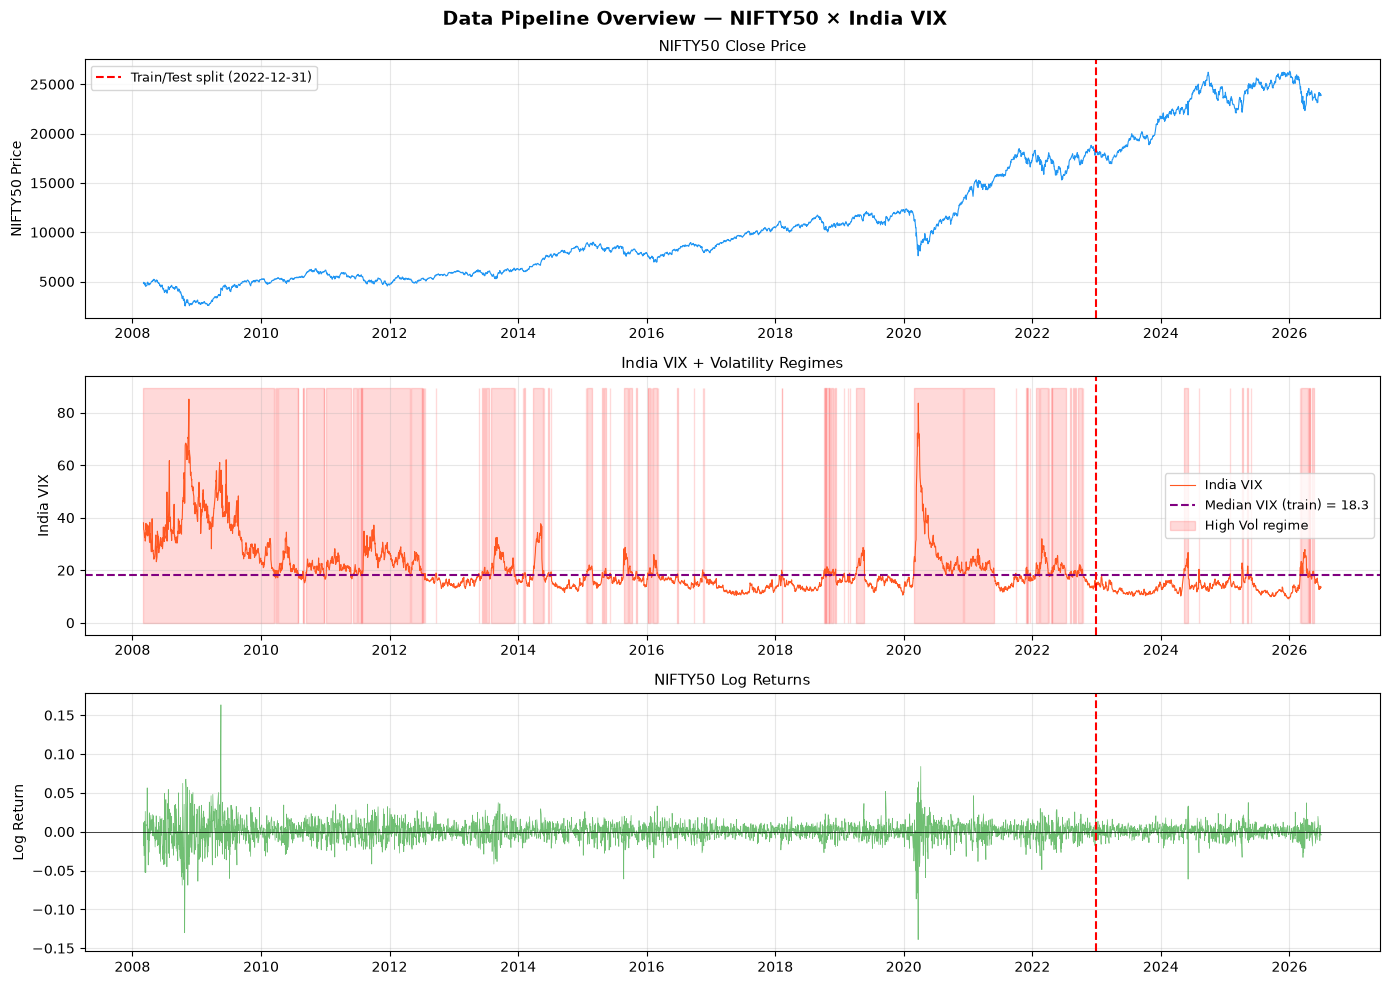

Figure saved: c:\Users\mahes\Downloads\IIT Mandi\nifty-ddpm\outputs\figures\nb01_data_overview.pdf


In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
fig.suptitle('Data Pipeline Overview — NIFTY50 × India VIX', fontsize=14, fontweight='bold')

# ── Plot 1: NIFTY price ───────────────────────────────────────
ax1 = axes[0]
ax1.plot(clean_df.index, clean_df['NIFTY'], color='#2196F3', linewidth=0.8)
ax1.axvline(pd.Timestamp(TRAIN_END), color='red', linestyle='--', linewidth=1.5,
            label=f'Train/Test split ({TRAIN_END})')
ax1.set_ylabel('NIFTY50 Price', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_title('NIFTY50 Close Price', fontsize=11)

# ── Plot 2: India VIX with regime shading ─────────────────────
ax2 = axes[1]
ax2.plot(clean_df.index, clean_df['VIX'], color='#FF5722', linewidth=0.8, label='India VIX')
ax2.axhline(vix_median_train, color='purple', linestyle='--', linewidth=1.5,
            label=f'Median VIX (train) = {vix_median_train:.1f}')
ax2.axvline(pd.Timestamp(TRAIN_END), color='red', linestyle='--', linewidth=1.5)
# Shade high-vol periods
high_mask = clean_df['VIX'] > vix_median_train
ax2.fill_between(clean_df.index, 0, clean_df['VIX'].max() * 1.05,
                 where=high_mask, alpha=0.15, color='red', label='High Vol regime')
ax2.set_ylabel('India VIX', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_title('India VIX + Volatility Regimes', fontsize=11)

# ── Plot 3: Log returns ───────────────────────────────────────
ax3 = axes[2]
ax3.plot(clean_df.index, clean_df['log_return'], color='#4CAF50', linewidth=0.5, alpha=0.8)
ax3.axvline(pd.Timestamp(TRAIN_END), color='red', linestyle='--', linewidth=1.5)
ax3.axhline(0, color='black', linewidth=0.5)
ax3.set_ylabel('Log Return', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_title('NIFTY50 Log Returns', fontsize=11)

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, 'nb01_data_overview.pdf')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.savefig(fig_path.replace('.pdf', '.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {fig_path}')

## Cell 13 — Sample Window Visualisation

Plot a few actual windows that the DDPM will see during training — Low Vol vs High Vol side by side.

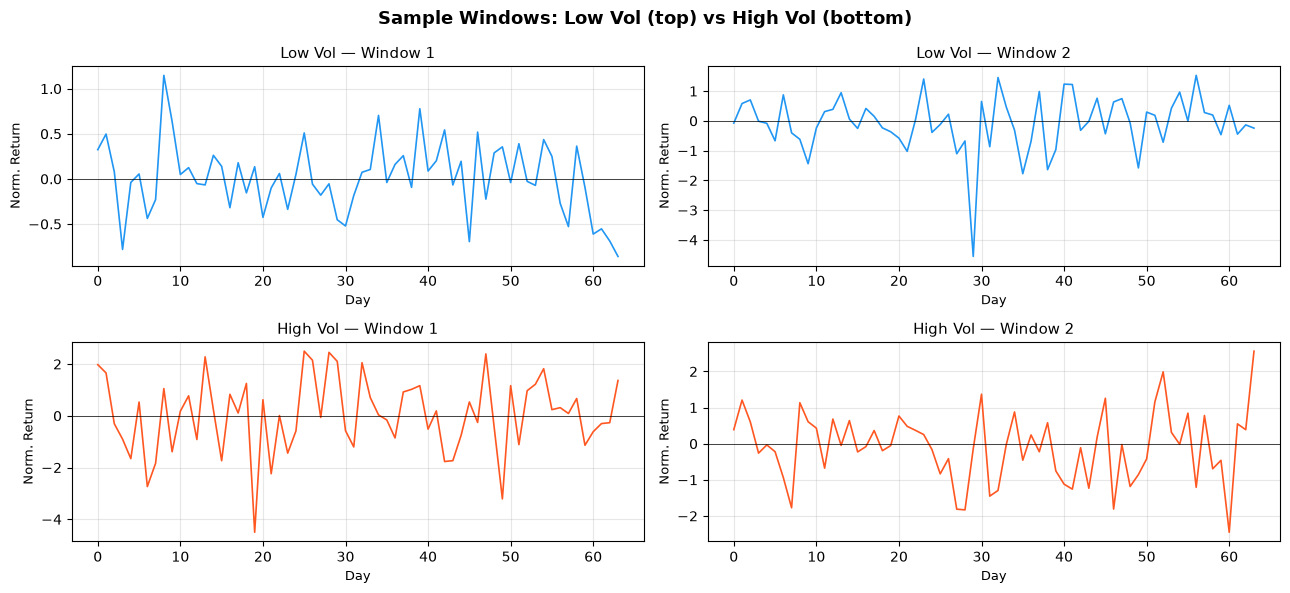

Figure saved: c:\Users\mahes\Downloads\IIT Mandi\nifty-ddpm\outputs\figures\nb01_sample_windows.pdf


In [14]:
np.random.seed(SEED)

# Pick 2 Low-Vol and 2 High-Vol windows
low_idx  = np.where(train_reg == 0)[0]
high_idx = np.where(train_reg == 1)[0]

low_samples  = train_ret[np.random.choice(low_idx,  2, replace=False)]
high_samples = train_ret[np.random.choice(high_idx, 2, replace=False)]

fig, axes = plt.subplots(2, 2, figsize=(13, 6))
fig.suptitle('Sample Windows: Low Vol (top) vs High Vol (bottom)', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes[0]):  # Low Vol
    ax.plot(low_samples[i], color='#2196F3', linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'Low Vol — Window {i+1}', fontsize=11)
    ax.set_xlabel('Day', fontsize=9)
    ax.set_ylabel('Norm. Return', fontsize=9)
    ax.grid(True, alpha=0.3)

for i, ax in enumerate(axes[1]):  # High Vol
    ax.plot(high_samples[i], color='#FF5722', linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'High Vol — Window {i+1}', fontsize=11)
    ax.set_xlabel('Day', fontsize=9)
    ax.set_ylabel('Norm. Return', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_path2 = os.path.join(FIG_DIR, 'nb01_sample_windows.pdf')
plt.savefig(fig_path2, dpi=150, bbox_inches='tight')
plt.savefig(fig_path2.replace('.pdf', '.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {fig_path2}')

## ✅ Notebook 01 Complete

### What was produced

| Output | Path | Description |
|--------|------|-------------|
| `nifty_vix_raw.csv` | `data/raw/` | Raw downloaded prices |
| `norm_params.json` | `data/processed/` | μ, σ for returns + VIX (needed for de-normalisation) |
| `train_processed.csv` | `data/processed/` | Cleaned train DataFrame |
| `test_processed.csv` | `data/processed/` | Cleaned test DataFrame |
| `return_statistics.csv` | `data/processed/` | Stats table for paper Section 3.1 |
| `train_windows.pt` | `data/windows/` | Train tensors: returns [N,64], vix [N,1], regime [N,1] |
| `test_windows.pt` | `data/windows/` | Test tensors: same format |
| `nb01_data_overview.pdf/png` | `outputs/figures/` | NIFTY + VIX + Returns plot |
| `nb01_sample_windows.pdf/png` | `outputs/figures/` | Sample Low/High Vol windows |

### Next Step
→ **Notebook 02** (`02_eda.ipynb`) — Full exploratory data analysis with stylized fact checks